#### Trojan Detection Baseline Accuracy

In [1]:
# train_gcn_node_fixed.py
import os
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

NODE_CSV  = "GNNDatasets/node.csv"
EDGE_CSV  = "GNNDatasets/node_edges.csv"
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

# ----------------------------- Load nodes -----------------------------
nodes_df = pd.read_csv(NODE_CSV)

label_col = None
for cand in ["label", "is_trojan", "trojan", "target"]:
    if cand in nodes_df.columns:
        label_col = cand; break
if label_col is None:
    nodes_df["label"] = nodes_df["circuit_name"].astype(str).str.contains("__trojan_").astype(int)
    label_col = "label"

nodes_df["uid"] = nodes_df["circuit_name"].astype(str) + "::" + nodes_df["node"].astype(str)

feat_df = nodes_df.copy()
if "gate_type" in feat_df.columns:
    gate_oh = pd.get_dummies(feat_df["gate_type"], prefix="gt")
    feat_df = pd.concat([feat_df.drop(columns=["gate_type"]), gate_oh], axis=1)

exclude = {"uid","node","circuit_name",label_col}
num_cols = [c for c in feat_df.columns if c not in exclude and pd.api.types.is_numeric_dtype(feat_df[c])]
X = feat_df[num_cols].fillna(0.0).values.astype(np.float32)
y = nodes_df[label_col].values.astype(np.int64)

# ----------------------------- Load edges; add missing nodes -----------------------------
edges_df = pd.read_csv(EDGE_CSV)
edges_df["src_uid"] = edges_df["circuit_name"].astype(str) + "::" + edges_df["src"].astype(str)
edges_df["dst_uid"] = edges_df["circuit_name"].astype(str) + "::" + edges_df["dst"].astype(str)

known_uids = set(nodes_df["uid"])
edge_uids = set(edges_df["src_uid"]).union(set(edges_df["dst_uid"]))
missing = list(edge_uids - known_uids)

if missing:
    zero_row = np.zeros((1, X.shape[1]), dtype=np.float32)
    addX = np.repeat(zero_row, len(missing), axis=0)
    addY = -1*np.ones(len(missing), dtype=np.int64)
    add_df = pd.DataFrame({
        "uid": missing,
        "circuit_name": [u.split("::",1)[0] for u in missing],
        "node": [u.split("::",1)[1] for u in missing],
        label_col: addY
    })
    X = np.vstack([X, addX])
    y = np.concatenate([y, addY])
    nodes_df = pd.concat([nodes_df, add_df], ignore_index=True)

uid_to_idx = {u:i for i,u in enumerate(nodes_df["uid"].tolist())}
src_idx = edges_df["src_uid"].map(uid_to_idx).dropna().astype(int).values
dst_idx = edges_df["dst_uid"].map(uid_to_idx).dropna().astype(int).values
edge_index = np.stack([np.concatenate([src_idx, dst_idx]),
                       np.concatenate([dst_idx, src_idx])], axis=0)

# ----------------------------- Scale features -----------------------------
labeled_mask_np = (y >= 0)
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[labeled_mask_np] = scaler.fit_transform(X_scaled[labeled_mask_np])
if (~labeled_mask_np).any():
    X_scaled[~labeled_mask_np] = (X_scaled[~labeled_mask_np] - scaler.mean_) / np.sqrt(scaler.var_ + 1e-8)

# ----------------------------- Splits -----------------------------
idx_all = np.where(labeled_mask_np)[0]
y_all = y[labeled_mask_np]

idx_train, idx_tmp, y_train, y_tmp = train_test_split(
    idx_all, y_all, test_size=0.30, random_state=SEED, stratify=y_all
)
idx_val, idx_test, y_val, y_test = train_test_split(
    idx_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp
)

# ----------------------------- Torch tensors (FIX: masks as torch.bool) -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_t = torch.from_numpy(X_scaled).to(device)
y_t = torch.from_numpy(y).to(device)

edge_index_t = torch.from_numpy(edge_index).long().to(device)

train_mask_t = torch.zeros(len(y), dtype=torch.bool, device=device); train_mask_t[idx_train] = True
val_mask_t   = torch.zeros(len(y), dtype=torch.bool, device=device); val_mask_t[idx_val]   = True
test_mask_t  = torch.zeros(len(y), dtype=torch.bool, device=device); test_mask_t[idx_test]  = True
labeled_mask_t = torch.from_numpy(labeled_mask_np).to(device)

# ----------------------------- Build GCN adjacency -----------------------------
def build_adj(num_nodes, edge_index):
    self_loops = torch.arange(num_nodes, device=edge_index.device)
    ei = torch.cat([edge_index, torch.stack([self_loops, self_loops])], dim=1)
    deg = torch.bincount(ei[0], minlength=num_nodes).float()
    deg_inv_sqrt = deg.clamp(min=1).pow(-0.5)
    w = deg_inv_sqrt[ei[0]] * deg_inv_sqrt[ei[1]]
    A = torch.sparse_coo_tensor(ei, w, (num_nodes, num_nodes))
    return A.coalesce()

A_t = build_adj(X_t.size(0), edge_index_t)

# ----------------------------- Model -----------------------------
class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.0):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim, bias=False)
        self.dropout = nn.Dropout(dropout)
        nn.init.xavier_uniform_(self.lin.weight)
    def forward(self, x, adj):
        x = self.dropout(x)
        x = torch.sparse.mm(adj, x)
        x = self.lin(x)
        return x

class GCN(nn.Module):
    def __init__(self, in_dim, hid_dim=96, out_dim=2, dropout=0.35):
        super().__init__()
        self.g1 = GCNLayer(in_dim, hid_dim, dropout)
        self.g2 = GCNLayer(hid_dim, out_dim, dropout)
        self.do = nn.Dropout(dropout)
    def forward(self, x, adj):
        x = self.g1(x, adj); x = F.relu(x); x = self.do(x)
        x = self.g2(x, adj)
        return x

model = GCN(in_dim=X_t.size(1), hid_dim=96, out_dim=2, dropout=0.35).to(device)

# ----------------------------- Loss, optimizer -----------------------------
train_labels = y_t[train_mask_t]
classes, counts = torch.unique(train_labels, return_counts=True)
num_pos = counts[classes==1].item() if (classes==1).any() else 1
num_neg = counts[classes==0].item() if (classes==0).any() else 1
weight_pos = (num_neg + num_pos) / (2.0 * num_pos)
weight_neg = (num_neg + num_pos) / (2.0 * num_neg)
class_weights = torch.tensor([weight_neg, weight_pos], dtype=torch.float32, device=device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3, weight_decay=5e-4)

# ----------------------------- Training -----------------------------
def evaluate(mask_t):
    model.eval()
    with torch.no_grad():
        logits = model(X_t, A_t)
        pred = logits.argmax(dim=1)
        msk = mask_t & (y_t >= 0)
        if msk.sum() == 0: return 0.0
        return (pred[msk] == y_t[msk]).float().mean().item()

best_val, best_state = -1.0, None
patience, patience_cnt = 20, 0
EPOCHS = 300

for epoch in range(1, EPOCHS+1):
    model.train()
    optimizer.zero_grad()
    logits = model(X_t, A_t)
    loss = criterion(logits[train_mask_t], y_t[train_mask_t])
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), 2.0)
    optimizer.step()

    if epoch % 10 == 0 or epoch == 1:
        val_acc = evaluate(val_mask_t)
        test_acc = evaluate(test_mask_t)
        print(f"Epoch {epoch:03d} | Loss {loss.item():.4f} | Val {val_acc:.4f} | Test {test_acc:.4f}")
        if val_acc > best_val + 1e-4:
            best_val = val_acc
            best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print("Early stopping."); break

if best_state is not None:
    model.load_state_dict(best_state)

# ----------------------------- Final eval -----------------------------
model.eval()
with torch.no_grad():
    logits = model(X_t, A_t)
    preds = logits.argmax(dim=1)

msk = (test_mask_t & (y_t >= 0)).cpu().numpy()
y_true = y_t.cpu().numpy()[msk]
y_pred = preds.cpu().numpy()[msk]

acc = (y_true == y_pred).mean()
print("\nFinal Evaluation (Node-Level)")
print("=============================")
print(f"Test Accuracy: {acc:.4f}\n")

print("Classification Report:")
print(classification_report(y_true, y_pred, labels=[0,1], target_names=["clean","trojan"], digits=4))

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred, labels=[0,1]))

Epoch 001 | Loss 0.8936 | Val 0.4607 | Test 0.4631
Epoch 010 | Loss 0.6116 | Val 0.9505 | Test 0.9496
Epoch 020 | Loss 0.4193 | Val 0.9883 | Test 0.9885
Epoch 030 | Loss 0.2920 | Val 0.9927 | Test 0.9931
Epoch 040 | Loss 0.2113 | Val 0.9981 | Test 0.9981
Epoch 050 | Loss 0.1559 | Val 0.9994 | Test 0.9995
Epoch 060 | Loss 0.1176 | Val 0.9999 | Test 0.9998
Epoch 070 | Loss 0.0936 | Val 0.9999 | Test 0.9998
Epoch 080 | Loss 0.0780 | Val 1.0000 | Test 1.0000
Epoch 090 | Loss 0.0668 | Val 1.0000 | Test 1.0000
Epoch 100 | Loss 0.0553 | Val 1.0000 | Test 1.0000
Epoch 110 | Loss 0.0493 | Val 1.0000 | Test 1.0000
Epoch 120 | Loss 0.0435 | Val 1.0000 | Test 1.0000
Epoch 130 | Loss 0.0407 | Val 1.0000 | Test 1.0000
Epoch 140 | Loss 0.0371 | Val 1.0000 | Test 1.0000
Epoch 150 | Loss 0.0346 | Val 1.0000 | Test 1.0000
Epoch 160 | Loss 0.0329 | Val 1.0000 | Test 1.0000
Epoch 170 | Loss 0.0302 | Val 1.0000 | Test 1.0000
Epoch 180 | Loss 0.0283 | Val 1.0000 | Test 1.0000
Epoch 190 | Loss 0.0273 | Val 1

Starting GBLA recon attack on trojan detection model...
Attacking class 0: 100 nodes ...
Attacking class 1: 100 nodes ...

Reconstruction error summary (scaled-feature L2):
 Class 0: n=100 | mean=3.0501 | std=1.8733 | med=2.3519
 Class 1: n=100 | mean=6.0643 | std=7.5257 | med=5.9982


/tmp/ipykernel_99169/1896627078.py:159: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(ordered_errors, labels=ordered_labels, showfliers=False)
/tmp/ipykernel_99169/1896627078.py:164: UserWarning: Glyph 151 (\x97) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_99169/1896627078.py:165: UserWarning: Glyph 151 (\x97) missing from font(s) DejaVu Sans.
  plt.savefig(SAVE_PLOT, dpi=200)



Boxplot saved to: reconstruction_errors_trojan_boxplot.png


/home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 151 (\x97) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


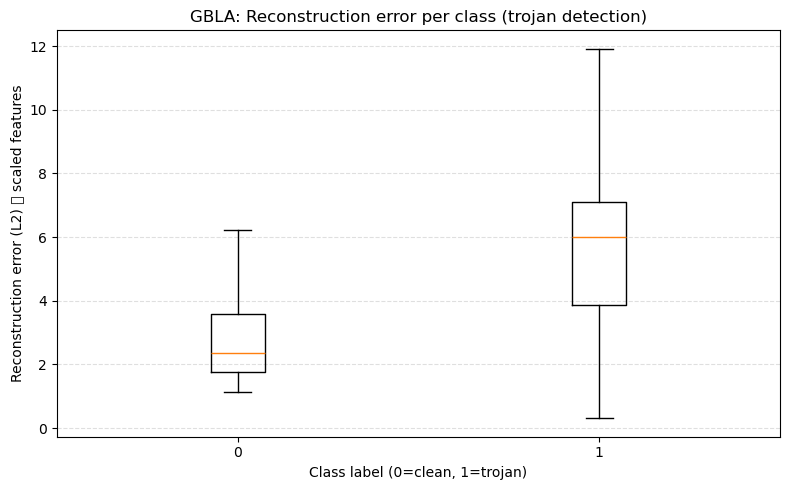

In [2]:
# gbla_trojan_recon.py
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# === ATTACK HYPERPARAMS ===
ATTACK_ITERATIONS = 300       # iterations to optimize dummy feature per node
ATTACKS_PER_CLASS = 100      # max nodes attacked per class (use available)
DUMMY_LR = 0.1
L2_REG = 0.001
RANDOM_SEED = 42
SAVE_PLOT = "reconstruction_errors_trojan_boxplot.png"

# Set seeds
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


# === If variables missing, raise friendly error ===
required_names = ["model", "X_t", "y_t", "A_t", "train_mask_t"]
missing = [n for n in required_names if n not in globals()]
if missing:
    raise RuntimeError(f"Missing variables in the environment required by this script: {missing}\n"
                       f"Run this script after training (same process) or load model/X/y/masks into scope.")

device = next(model.parameters()).device

# Work in eval mode and freeze model params
model.eval()
for p in model.parameters():
    p.requires_grad = True  # we need gradients w.r.t. model params for the target gradient computation

# Helper: gather train indices with labels (>=0)
train_idx_all = torch.nonzero(train_mask_t & (y_t >= 0), as_tuple=False).view(-1).cpu().numpy().tolist()

# Map classes present in train set
train_labels = y_t[train_mask_t].cpu().numpy()
classes_present = np.unique(train_labels).tolist()  # e.g. [0,1] (clean=0, trojan=1)

# For reproducibility
rng = np.random.default_rng(RANDOM_SEED)

# Store reconstruction errors per class label
reconstruction_errors = {int(c): [] for c in classes_present}

# Precompute original features (scaled) and move to device
features_orig = X_t.clone().detach()

# --- Attack main loop ---
print("Starting GBLA recon attack on trojan detection model...")
for class_val in classes_present:
    # candidate indices in the training set that have this label
    candidate_indices = [int(idx) for idx in train_idx_all if int(y_t[idx].item()) == int(class_val)]
    if len(candidate_indices) == 0:
        print(f" - No training candidates for class {class_val}; skipping.")
        continue

    # select up to ATTACKS_PER_CLASS nodes
    if len(candidate_indices) <= ATTACKS_PER_CLASS:
        target_indices = candidate_indices
    else:
        target_indices = list(rng.choice(candidate_indices, size=ATTACKS_PER_CLASS, replace=False))

    print(f"Attacking class {class_val}: {len(target_indices)} nodes ...")
    for target_idx in target_indices:
        # ----------------------
        # 1) compute target gradients for this node (attacker has access to per-node gradient)
        # ----------------------
        model.zero_grad()

        # forward with original features
        logits = model(features_orig.to(device), A_t)
        # select logit and label for target node
        target_logit = logits[target_idx:target_idx+1]           # shape [1, num_classes]
        target_label = y_t[target_idx:target_idx+1].to(device)   # shape [1]

        # compute loss and backprop to collect gradients on model parameters
        loss_fn = nn.CrossEntropyLoss()
        target_loss = loss_fn(target_logit, target_label)
        target_loss.backward()

        # collect target gradients (one per model parameter)
        target_grads = []
        for p in model.parameters():
            if p.grad is None:
                target_grads.append(torch.zeros_like(p).detach())
            else:
                target_grads.append(p.grad.detach().clone())

        # ----------------------
        # 2) initialize dummy feature for the target node and optimize it
        # ----------------------
        # start from small noise (same shape as single-node feature vector)
        target_feat_shape = features_orig[target_idx:target_idx+1].shape  # [1, feat_dim]
        dummy_feat = torch.randn_like(features_orig[target_idx:target_idx+1], device=device, requires_grad=True)

        dummy_optimizer = optim.Adam([dummy_feat], lr=DUMMY_LR)

        for it in range(ATTACK_ITERATIONS):
            # build dummy feature matrix (copy of original but replace target node)
            dummy_features = features_orig.clone().to(device)
            dummy_features[target_idx:target_idx+1] = dummy_feat

            # zero model grads (we compute grads w.r.t model params from dummy loss)
            model.zero_grad()

            # compute dummy loss for the same node label
            dummy_logits = model(dummy_features, A_t)
            dummy_loss = loss_fn(dummy_logits[target_idx:target_idx+1], target_label)

            # compute gradients of dummy_loss w.r.t model parameters (create_graph=True to allow gradient backprop to dummy_feat)
            dummy_grads = torch.autograd.grad(dummy_loss, tuple(model.parameters()), create_graph=True, allow_unused=True)

            # compute gradient-difference loss (sum squared differences over all parameters)
            grad_diff_loss = torch.tensor(0.0, device=device)
            for dg, tg in zip(dummy_grads, target_grads):
                # dg may be None if parameter did not receive gradient; replace with zeros
                if dg is None:
                    dg = torch.zeros_like(tg, device=device)
                grad_diff_loss = grad_diff_loss + torch.sum((dg - tg.to(device)) ** 2)

            # L2 regularization on dummy feature for stability
            reg_loss = torch.norm(dummy_feat, p=2)
            total_loss = grad_diff_loss + L2_REG * reg_loss

            # gradient step on dummy feature
            dummy_optimizer.zero_grad()
            total_loss.backward()
            dummy_optimizer.step()

        # ----------------------
        # 3) measure reconstruction error (L2) in scaled feature space
        # ----------------------
        recon_error = torch.norm(dummy_feat.detach().cpu() - features_orig[target_idx:target_idx+1].cpu(), p=2).item()
        reconstruction_errors[int(class_val)].append(recon_error)

# --- After all attacks: plotting and saving ---
# Convert to lists ordered by class (0=clean, 1=trojan) if available
ordered_classes = sorted(reconstruction_errors.keys())
ordered_errors = [reconstruction_errors[c] for c in ordered_classes]
ordered_labels = [str(c) for c in ordered_classes]

# Print summary stats
print("\nReconstruction error summary (scaled-feature L2):")
for c, errs in zip(ordered_classes, ordered_errors):
    if len(errs) == 0:
        print(f" Class {c}: no data")
    else:
        errs_arr = np.array(errs)
        print(f" Class {c}: n={len(errs)} | mean={errs_arr.mean():.4f} | std={errs_arr.std():.4f} | med={np.median(errs_arr):.4f}")

# Plot boxplot
plt.figure(figsize=(8,5))
plt.boxplot(ordered_errors, labels=ordered_labels, showfliers=False)
plt.xlabel("Class label (0=clean, 1=trojan)")
plt.ylabel("Reconstruction error (L2)  scaled features")
plt.title("GBLA: Reconstruction error per class (trojan detection)")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(SAVE_PLOT, dpi=200)
print(f"\nBoxplot saved to: {SAVE_PLOT}")
plt.show()


/tmp/ipykernel_99169/1352477619.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(ordered_errors, labels=ordered_labels, showfliers=False)


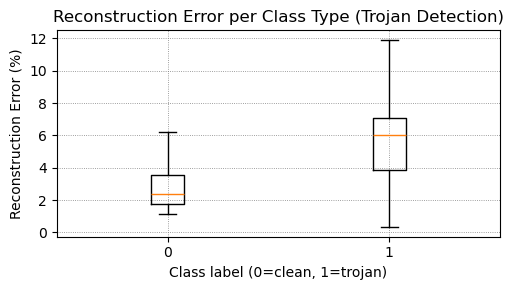

In [9]:
# Create the box plot
fig, ax = plt.subplots(figsize=(5.2, 3))
ax.boxplot(ordered_errors, labels=ordered_labels, showfliers=False)
ax.set_xlabel("Class label (0=clean, 1=trojan)")
ax.set_ylabel("Reconstruction Error (%)")
ax.set_title("Reconstruction Error per Class Type (Trojan Detection)")
ax.grid(color='gray', linestyle=':', linewidth=0.6)

plt.tight_layout()
plt.savefig("boxplot_HT_baseline.pdf", format="pdf")
plt.show()


#### Gradient leakage analysis under five defense strategies:
- Differential Privacy
- Gradient Clipping + Perturbation
- Secure Aggregation
- Model Quantization
- Adversarial Training


Running defense: none


Defense=none: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [1:52:12<00:00, 67.32s/it]



Running defense: dp


Defense=dp: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [1:42:15<00:00, 61.35s/it]



Running defense: clip


...

Defense=secure: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [1:56:49<00:00, 70.10s/it]



Running defense: quant


Defense=quant: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [1:45:19<00:00, 63.19s/it]



Running defense: advtrain


Defense=advtrain: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [1:25:36<00:00, 51.36s/it]


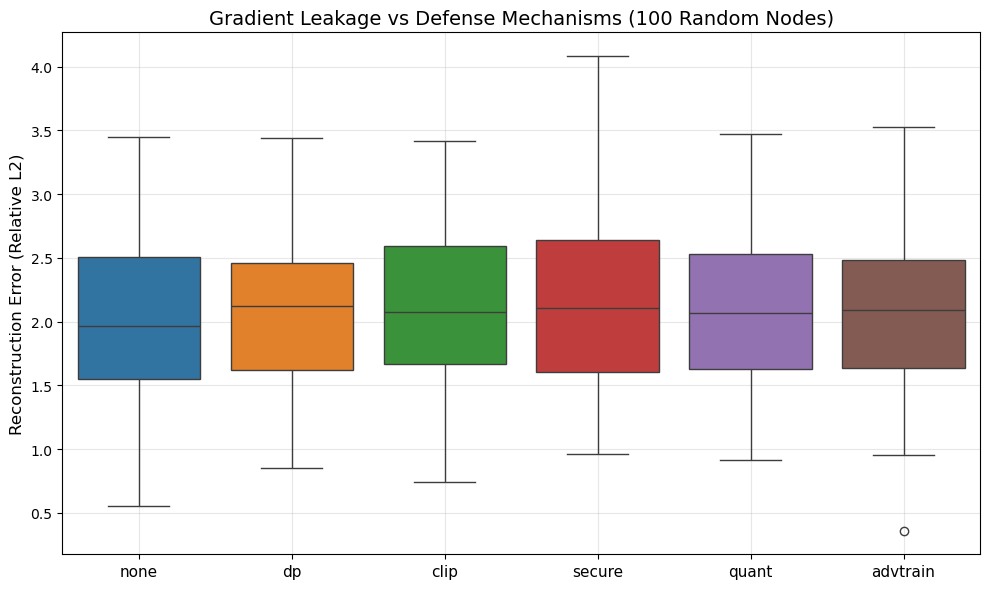


Mean ± Std of Reconstruction Error:
none      : 2.0404 ± 0.6717
dp        : 2.0970 ± 0.6277
clip      : 2.0932 ± 0.6070
secure    : 2.1636 ± 0.6889
quant     : 2.0669 ± 0.6043
advtrain  : 2.0805 ± 0.6135


In [11]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
from tqdm import tqdm

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)
model.eval()

# ----------------------------- Helper: gradient-based reconstruction -----------------------------
def reconstruct_features(model, X, A, target_idx, defense="none", steps=100, lr=0.05):
    """
    Reconstructs node features from gradients using a differentiable gradient matching loss.
    Uses torch.autograd.grad for correctness and speed.
    """
    x_true = X[target_idx].detach()
    y_true = y_t[target_idx].detach()

    # Compute reference gradients (no defense)
    model.zero_grad()
    logits = model(X, A)
    loss = F.cross_entropy(logits[target_idx].unsqueeze(0), y_true.unsqueeze(0))
    grads_true = torch.autograd.grad(loss, model.parameters(), create_graph=False, retain_graph=False)

    # Apply defense
    grads_true_mod = []
    for g in grads_true:
        if defense == "dp":
            g = g + 0.02 * torch.randn_like(g)
        elif defense == "clip":
            g = torch.clamp(g, -0.5, 0.5)
        elif defense == "secure":
            g = torch.zeros_like(g)
        elif defense == "quant":
            g = torch.round(g * 10) / 10
        elif defense == "advtrain":
            g = g + 0.01 * torch.sign(torch.randn_like(g))
        grads_true_mod.append(g.detach())

    # Start reconstruction
    x_recon = torch.randn_like(x_true, requires_grad=True)
    opt = torch.optim.Adam([x_recon], lr=lr)
    prev_loss = float("inf")

    for _ in range(steps):
        opt.zero_grad()
        X_mod = X.clone()
        X_mod[target_idx] = x_recon

        logits_r = model(X_mod, A)
        loss_r = F.cross_entropy(logits_r[target_idx].unsqueeze(0), y_true.unsqueeze(0))

        grads_rec = torch.autograd.grad(loss_r, model.parameters(), create_graph=True, retain_graph=True)
        diffs = [(gr - gt).pow(2).mean() for gr, gt in zip(grads_rec, grads_true_mod)]
        g_loss = torch.stack(diffs).mean()

        g_loss.backward()
        opt.step()

        # optional: early stop if loss stabilizes
        if abs(prev_loss - g_loss.item()) < 1e-5:
            break
        prev_loss = g_loss.item()

    return x_recon.detach(), x_true.detach()

# ----------------------------- Sample nodes -----------------------------
test_idx = torch.where(test_mask_t & (y_t >= 0))[0].cpu().numpy()
sample_nodes = np.random.choice(test_idx, size=min(100, len(test_idx)), replace=False)

# ----------------------------- Run all defenses -----------------------------
defenses = ["none", "dp", "clip", "secure", "quant", "advtrain"]
results = {d: [] for d in defenses}

for d in defenses:
    print(f"\nRunning defense: {d}")
    for idx in tqdm(sample_nodes, desc=f"Defense={d}"):
        xr, xt = reconstruct_features(model, X_t, A_t, idx, defense=d)
        err = torch.norm(xr - xt) / (torch.norm(xt) + 1e-8)
        results[d].append(err.item())

# ----------------------------- Combined boxplot -----------------------------
plt.figure(figsize=(10,6))
sns.boxplot(data=[results[d] for d in defenses])
plt.xticks(range(len(defenses)), defenses, fontsize=11)
plt.ylabel("Reconstruction Error (Relative L2)", fontsize=12)
plt.title("Gradient Leakage vs Defense Mechanisms (100 Random Nodes)", fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------------------- Summary table -----------------------------
summary = {d: (np.mean(results[d]), np.std(results[d])) for d in defenses}
print("\nMean ± Std of Reconstruction Error:")
for k,(m,s) in summary.items():
    print(f"{k:10s}: {m:.4f} ± {s:.4f}")


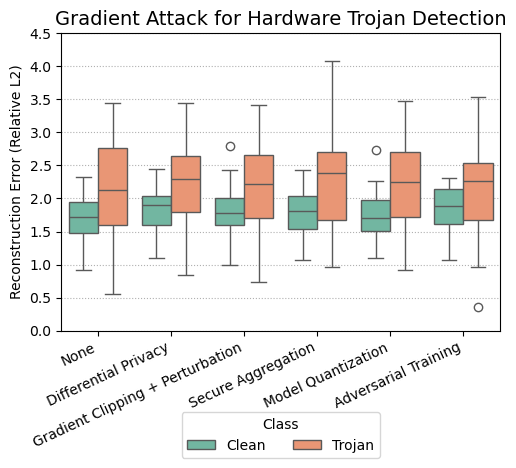


Mean ± Std of Reconstruction Error (per class and defense):
Adversarial Training                | Clean   | mean=1.8338 ± 0.3675 (n=23)
Adversarial Training                | Trojan  | mean=2.1542 ± 0.6574 (n=77)
Differential Privacy                | Clean   | mean=1.8190 ± 0.3337 (n=23)
Differential Privacy                | Trojan  | mean=2.1800 ± 0.6752 (n=77)
Gradient Clipping + Perturbation    | Clean   | mean=1.8331 ± 0.4167 (n=23)
Gradient Clipping + Perturbation    | Trojan  | mean=2.1709 ± 0.6387 (n=77)
Model Quantization                  | Clean   | mean=1.7622 ± 0.3729 (n=23)
Model Quantization                  | Trojan  | mean=2.1580 ± 0.6355 (n=77)
None                                | Clean   | mean=1.6928 ± 0.3553 (n=23)
None                                | Trojan  | mean=2.1443 ± 0.7138 (n=77)
Secure Aggregation                  | Clean   | mean=1.8024 ± 0.3652 (n=23)
Secure Aggregation                  | Trojan  | mean=2.2715 ± 0.7311 (n=77)


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Prepare mapping for defense names
defense_names = [
    'None',
    'Differential Privacy',
    'Gradient Clipping + Perturbation',
    'Secure Aggregation',
    'Model Quantization',
    'Adversarial Training'
]
defense_map = dict(zip(defenses, defense_names))

# Prepare data for combined plot
sample_labels = y_t[sample_nodes].cpu().numpy()
records = []

for d in defenses:
    errs = np.array(results[d])
    for lbl, e in zip(sample_labels, errs):
        if lbl in [0, 1]:
            records.append({
                "Defense": defense_map[d],
                "Class": "Clean" if lbl == 0 else "Trojan",
                "Error": e
            })

df_plot = pd.DataFrame(records)

# ----------------------------- Combined Box Plot -----------------------------
plt.figure(figsize=(5.2, 5))
sns.boxplot(
    data=df_plot,
    x="Defense",
    y="Error",
    hue="Class",
    palette="Set2"
)
plt.title("Gradient Attack for Hardware Trojan Detection", fontsize=14)
plt.ylabel("Reconstruction Error (Relative L2)")
plt.xlabel("")
plt.xticks(rotation=25, ha='right')

plt.legend(title="Class", loc='upper center', bbox_to_anchor=(0.5, -0.25), 
          ncol=2, frameon=True)
plt.grid(axis="y", linestyle=":", linewidth=0.8)
plt.yticks([0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5])
plt.tight_layout()
plt.savefig("boxplot_HT_alldefense.pdf", format="pdf")
plt.show()

# ----------------------------- Print summary table -----------------------------
print("\nMean ± Std of Reconstruction Error (per class and defense):")
summary = (
    df_plot.groupby(["Defense", "Class"])["Error"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
for _, row in summary.iterrows():
    print(f"{row['Defense']:35s} | {row['Class']:7s} | mean={row['mean']:.4f} ± {row['std']:.4f} (n={int(row['count'])})")


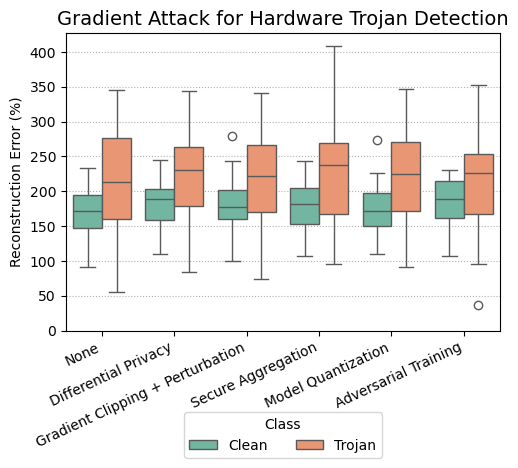


Mean ± Std of Reconstruction Error (per class and defense):
Adversarial Training                | Clean   | mean=183.38% ± 36.75% (n=23)
Adversarial Training                | Trojan  | mean=215.42% ± 65.74% (n=77)
Differential Privacy                | Clean   | mean=181.90% ± 33.37% (n=23)
Differential Privacy                | Trojan  | mean=218.00% ± 67.52% (n=77)
Gradient Clipping + Perturbation    | Clean   | mean=183.31% ± 41.67% (n=23)
Gradient Clipping + Perturbation    | Trojan  | mean=217.09% ± 63.87% (n=77)
Model Quantization                  | Clean   | mean=176.22% ± 37.29% (n=23)
Model Quantization                  | Trojan  | mean=215.80% ± 63.55% (n=77)
None                                | Clean   | mean=169.28% ± 35.53% (n=23)
None                                | Trojan  | mean=214.43% ± 71.38% (n=77)
Secure Aggregation                  | Clean   | mean=180.24% ± 36.52% (n=23)
Secure Aggregation                  | Trojan  | mean=227.15% ± 73.11% (n=77)


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Prepare mapping for defense names
defense_names = [
    'None',
    'Differential Privacy',
    'Gradient Clipping + Perturbation',
    'Secure Aggregation',
    'Model Quantization',
    'Adversarial Training'
]
defense_map = dict(zip(defenses, defense_names))

# Prepare data for combined plot
sample_labels = y_t[sample_nodes].cpu().numpy()
records = []

for d in defenses:
    errs = np.array(results[d]) * 100.0   # <-- convert to percentage
    for lbl, e in zip(sample_labels, errs):
        if lbl in [0, 1]:
            records.append({
                "Defense": defense_map[d],
                "Class": "Clean" if lbl == 0 else "Trojan",
                "Error": e
            })

df_plot = pd.DataFrame(records)

# ----------------------------- Combined Box Plot -----------------------------
plt.figure(figsize=(5.2, 5))
sns.boxplot(
    data=df_plot,
    x="Defense",
    y="Error",
    hue="Class",
    palette="Set2"
)
plt.title("Gradient Attack for Hardware Trojan Detection", fontsize=14)
plt.ylabel("Reconstruction Error (%)")
plt.xlabel("")
plt.xticks(rotation=25, ha='right')

plt.legend(title="Class", loc='upper center', bbox_to_anchor=(0.5, -0.25), 
          ncol=2, frameon=True)
plt.grid(axis="y", linestyle=":", linewidth=0.8)
plt.yticks([0, 50, 100, 150, 200, 250, 300, 350, 400])
plt.tight_layout()
plt.savefig("boxplot_HT_errorpecentage_alldefense.pdf", format="pdf")
plt.show()

# ----------------------------- Print summary table -----------------------------
print("\nMean ± Std of Reconstruction Error (per class and defense):")
summary = (
    df_plot.groupby(["Defense", "Class"])["Error"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
for _, row in summary.iterrows():
    print(f"{row['Defense']:35s} | {row['Class']:7s} | mean={row['mean']:.2f}% ± {row['std']:.2f}% (n={int(row['count'])})")


#### Rerun for all the metrics abs_l2, rel_l2, and cos_sim.

In [5]:
import torch
import torch.nn.functional as F
import numpy as np
import random
from tqdm import tqdm

# === ATTACK HYPERPARAMS ===
ATTACK_ITERATIONS = 300       # iterations to optimize dummy feature per node
ATTACKS_PER_CLASS = 20      # max nodes attacked per class (use available)
DUMMY_LR = 0.1
L2_REG = 0.001
RANDOM_SEED = 42

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)
model.eval()

# ----------------------------- Helper: gradient-based reconstruction -----------------------------
def reconstruct_features(model, X, A, target_idx, defense="none", steps=100, lr=0.05):
    """
    Reconstructs node features from gradients using differentiable gradient matching.
    Returns both reconstructed and true feature vectors.
    """
    x_true = X[target_idx].detach()
    y_true = y_t[target_idx].detach()

    # Compute reference gradients (ground truth)
    model.zero_grad()
    logits = model(X, A)
    loss = F.cross_entropy(logits[target_idx].unsqueeze(0), y_true.unsqueeze(0))
    grads_true = torch.autograd.grad(loss, model.parameters(), create_graph=False, retain_graph=False)

    # Apply defense
    grads_true_mod = []
    for g in grads_true:
        if defense == "dp":
            g = g + 0.02 * torch.randn_like(g)
        elif defense == "clip":
            g = torch.clamp(g, -0.5, 0.5)
        elif defense == "secure":
            g = torch.zeros_like(g)
        elif defense == "quant":
            g = torch.round(g * 10) / 10
        elif defense == "advtrain":
            g = g + 0.01 * torch.sign(torch.randn_like(g))
        grads_true_mod.append(g.detach())

    # Dummy feature initialization
    x_recon = torch.randn_like(x_true, requires_grad=True)
    opt = torch.optim.Adam([x_recon], lr=lr)
    prev_loss = float("inf")

    for _ in range(steps):
        opt.zero_grad()
        X_mod = X.clone()
        X_mod[target_idx] = x_recon

        logits_r = model(X_mod, A)
        loss_r = F.cross_entropy(logits_r[target_idx].unsqueeze(0), y_true.unsqueeze(0))

        grads_rec = torch.autograd.grad(loss_r, model.parameters(), create_graph=True, retain_graph=True)
        diffs = [(gr - gt).pow(2).mean() for gr, gt in zip(grads_rec, grads_true_mod)]
        g_loss = torch.stack(diffs).mean()

        g_loss.backward()
        opt.step()

        if abs(prev_loss - g_loss.item()) < 1e-5:
            break
        prev_loss = g_loss.item()

    return x_recon.detach(), x_true.detach(), y_true.item()

# ----------------------------- Sample nodes -----------------------------
test_idx = torch.where(test_mask_t & (y_t >= 0))[0].cpu().numpy()
sample_nodes = np.random.choice(test_idx, size=min(ATTACKS_PER_CLASS, len(test_idx)), replace=False)

# ----------------------------- Run all defenses -----------------------------
defenses = ["none", "dp", "clip", "secure", "quant", "advtrain"]
results = {d: {"abs_l2": [], "rel_l2": [], "cos_sim": [], "labels": []} for d in defenses}

for d in defenses:
    print(f"\nRunning defense: {d}")
    for idx in tqdm(sample_nodes, desc=f"Defense={d}"):
        xr, xt, lbl = reconstruct_features(model, X_t, A_t, idx, defense=d)

        abs_l2 = torch.norm(xr - xt).item()
        rel_l2 = abs_l2 / (torch.norm(xt).item() + 1e-8)
        cos_sim = F.cosine_similarity(xr.unsqueeze(0), xt.unsqueeze(0)).item()

        results[d]["abs_l2"].append(abs_l2)
        results[d]["rel_l2"].append(rel_l2)
        results[d]["cos_sim"].append(cos_sim)
        results[d]["labels"].append(lbl)

# ----------------------------- Summary by defense and label -----------------------------
print("\n=== Gradient-Based Leakage Results (Hardware Trojan Detection) ===\n")

for d in defenses:
    labels = np.array(results[d]["labels"])
    abs_l2 = np.array(results[d]["abs_l2"])
    rel_l2 = np.array(results[d]["rel_l2"])
    cos_sim = np.array(results[d]["cos_sim"])

    print(f"Defense: {d}")
    for lbl_name, lbl_val in zip(["Clean", "Trojan"], [0, 1]):
        mask = (labels == lbl_val)
        if mask.sum() == 0:
            continue
        print(f"  Label = {lbl_name:<7s} | "
              f"abs_l2: {abs_l2[mask].mean():.4f} ± {abs_l2[mask].std():.4f} | "
              f"rel_l2: {rel_l2[mask].mean():.4f} ± {rel_l2[mask].std():.4f} | "
              f"cos_sim: {cos_sim[mask].mean():.4f} ± {cos_sim[mask].std():.4f}")
    print()

# ----------------------------- Overall summary -----------------------------
print("=== Overall Summary (All Labels Combined) ===")
for d in defenses:
    abs_l2 = np.array(results[d]["abs_l2"])
    rel_l2 = np.array(results[d]["rel_l2"])
    cos_sim = np.array(results[d]["cos_sim"])
    print(f"{d:10s}: abs_l2={abs_l2.mean():.4f} | rel_l2={rel_l2.mean():.4f} | cos_sim={cos_sim.mean():.4f}")



Running defense: none


Defense=none: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [22:08<00:00, 66.43s/it]



Running defense: dp


Defense=dp: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [27:12<00:00, 81.60s/it]



Running defense: clip


...


Running defense: quant


Defense=quant: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [39:48<00:00, 119.42s/it]



Running defense: advtrain


Defense=advtrain: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [23:51<00:00, 71.58s/it]


=== Gradient-Based Leakage Results (Hardware Trojan Detection) ===

Defense: none
  Label = Clean   | abs_l2: 7.5885 ± 2.1720 | rel_l2: 1.5654 ± 0.5825 | cos_sim: 0.1712 ± 0.1686
  Label = Trojan  | abs_l2: 6.4793 ± 1.9334 | rel_l2: 2.2150 ± 0.7332 | cos_sim: 0.1272 ± 0.2800

Defense: dp
  Label = Clean   | abs_l2: 7.1580 ± 2.8482 | rel_l2: 1.3796 ± 0.3811 | cos_sim: 0.2159 ± 0.1083
  Label = Trojan  | abs_l2: 6.7347 ± 2.4030 | rel_l2: 2.2600 ± 0.6963 | cos_sim: 0.0351 ± 0.3302

Defense: clip
  Label = Clean   | abs_l2: 7.7930 ± 3.7373 | rel_l2: 1.4580 ± 0.4321 | cos_sim: 0.1354 ± 0.1797
  Label = Trojan  | abs_l2: 6.9137 ± 3.2059 | rel_l2: 2.2442 ± 0.6588 | cos_sim: -0.0404 ± 0.2667

Defense: secure
  Label = Clean   | abs_l2: 8.0910 ± 3.6354 | rel_l2: 1.4903 ± 0.2710 | cos_sim: 0.1014 ± 0.2044
  Label = Trojan  | abs_l2: 6.4865 ± 2.9957 | rel_l2: 2.1174 ± 0.5837 | cos_sim: 0.0455 ± 0.1826

Defense: quant
  Label = Clean   | abs_l2: 7.7417 ± 2.9713 | rel_l2: 1.4959 ± 0.3968 | cos_sim